# **Exploratory Data Analysis (EDA)**

In [20]:
import warnings 
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys 

from pathlib import Path 

In [21]:
from train import DATASET_PATH
from utils import load_dataset

df = load_dataset(DATASET_PATH)


Dataset Loaded Successfully


In [22]:
df.head()

,Area,Price
0,801,2542000
1,801,2461000
2,801,2452000
3,802,2450000
4,803,2300000


In [23]:
df.tail()

,Area,Price
4995,3697,12908000
4996,3699,13008000
4997,3699,13021000
4998,3700,12973000
4999,3700,13103000


In [24]:
df.sample(10, random_state=42)

,Area,Price
1501,1704,5767000
2586,2323,7948000
2653,2362,8168000
1055,1435,4806000
705,1217,4002000
106,863,2670000
589,1148,3640000
2468,2253,7607000
2413,2222,7584000
1600,1767,5838000


In [25]:
print(f"Shape of Dataset         : {df.shape}")
print(f"Total Rows in Dataset    : {df.shape[0]}")
print(f"Total Columns in Dataset : {df.shape[1]}")

Shape of Dataset         : (5000, 2)
Total Rows in Dataset    : 5000
Total Columns in Dataset : 2


In [26]:
print("ALL Columns in Dataset: ", df.columns.tolist())

ALL Columns in Dataset:  ['Area', 'Price']


In [27]:
print("Dataset Info: ")
df.info()

Dataset Info: 
<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Area    5000 non-null   int64
 1   Price   5000 non-null   int64
dtypes: int64(2)
memory usage: 78.3 KB


In [28]:
null_values = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": (df.isnull().sum()/len(df)*100).round(2)
})

null_values.head()

,Missing Values,Percentage
Area,0,0.0
Price,0,0.0


In [29]:
duplicates = df.duplicated().sum()

print(f"Duplicate Rows : {duplicates}")

Duplicate Rows : 13


In [30]:
print("Dataset Description: ")
df.describe().T

Dataset Description: 


,count,mean,std,min,25%,50%,75%,max
Area,5000.0,2.263401e+03,8.310104e+02,801.0,1555.5,2277.5,2984.0,3700.0
Price,5000.0,7.781280e+06,3.027380e+06,2300000.0,5193500.0,7835500.0,10408000.0,13103000.0


In [31]:
print("Dataset's Datatype: ")
df.dtypes

Dataset's Datatype: 


Area     int64
Price    int64
dtype: object

In [32]:
print("Number of Unique Values: ")
df.nunique()

Number of Unique Values: 


Area     2376
Price    3980
dtype: int64

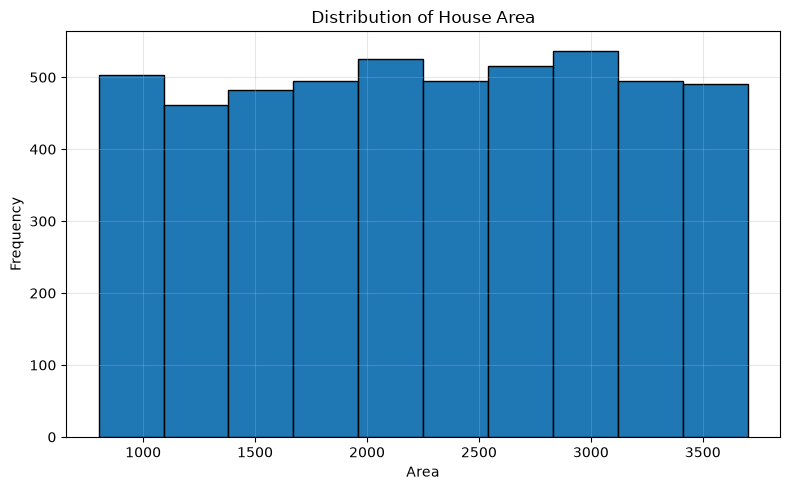

In [33]:
plt.figure(figsize=(8,5))

plt.hist(
    df["Area"],
    bins=10,
    edgecolor="black"
)

plt.title("Distribution of House Area")
plt.xlabel("Area")
plt.ylabel("Frequency")
plt.grid(alpha=.3)
plt.tight_layout()
plt.show()

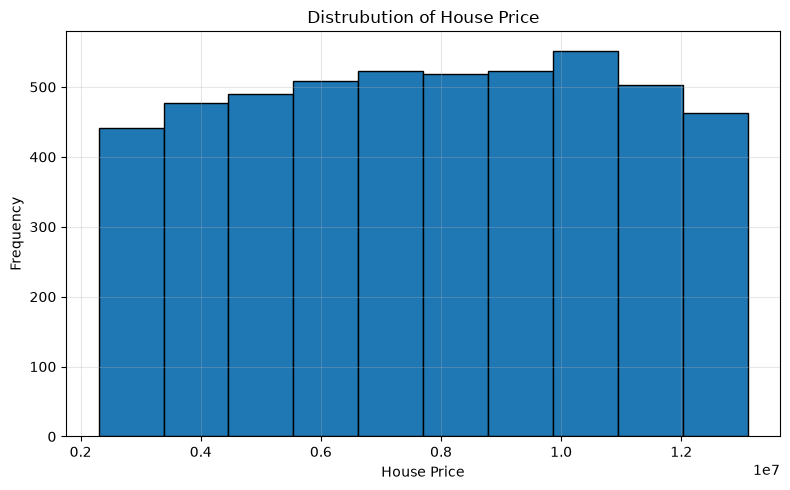

In [34]:
plt.figure(figsize=(8,5))

plt.hist(
    df['Price'],
    bins=10,
    edgecolor="black"
)

plt.title("Distrubution of House Price")
plt.xlabel("House Price")
plt.ylabel("Frequency")
plt.grid(alpha=.3)
plt.tight_layout()
plt.show()

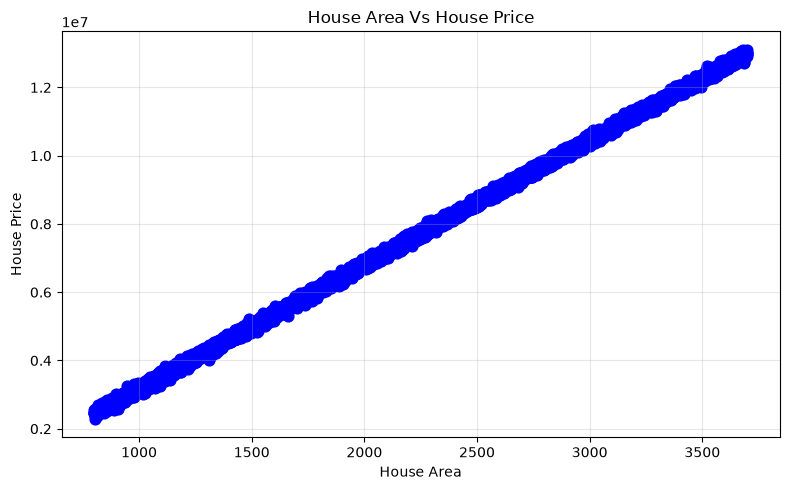

In [35]:
plt.figure(figsize=(8,5))

plt.scatter(
    df['Area'],
    df['Price'],
    color='blue',
    s=60
)

plt.title("House Area Vs House Price")
plt.xlabel("House Area")
plt.ylabel("House Price")

plt.grid(alpha=.3)
plt.tight_layout()
plt.show()

In [36]:
print("Prining Correlation between columns: ")

df.corr(numeric_only=True)

Prining Correlation between columns: 


,Area,Price
Area,1.000000,0.999655
Price,0.999655,1.000000


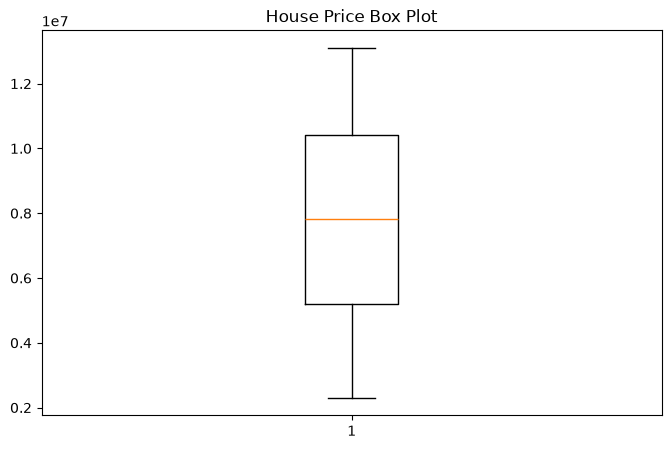

In [37]:
plt.figure(figsize=(8,5))

plt.boxplot(df["Price"])

plt.title("House Price Box Plot")

plt.show()

In [38]:
Q1 = df['Price'].quantile(.25)
Q3 = df['Price'].quantile(.75)

IQR = Q3 - Q1

lower = Q1-1.5*IQR
upper = Q1+1.5*IQR

outliers = df[
    (df["Price"]<lower) | (df["Price"]>upper)
]

outliers

,Area,Price
4959,3673,13056000
4967,3675,13018000
4973,3681,13019000
4974,3681,13083000
4979,3685,13028000
4986,3689,13039000
4989,3692,13043000
4994,3696,13062000
4997,3699,13021000
4999,3700,13103000


In [39]:
print("="*70)
print("DATA QUALITY REPORT")
print("="*70)
print(f"Rows : {len(df)}")
print(f"Columns : {len(df.columns)}")
print(f"Missing Values : {df.isnull().sum().sum()}")
print(f"Duplicate Rows : {df.duplicated().sum()}")
print(f"Outliers : {len(outliers)}")
print("="*70)

DATA QUALITY REPORT
Rows : 5000
Columns : 2
Missing Values : 0
Duplicate Rows : 13
Outliers : 10
